### Cell 0
# 予備実験
* 目的：閾値の決定

### Cell 1
## Matplotlib のインストール
* インストールしてる場合は実行しなくて良い

In [19]:
# Cell 2
!pip3 install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 23.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 kB 31.9 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 56.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 61.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 14.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


### Cell 3
## <font color="red">要実行</font>

In [1]:
# Cell 4
# モジュールの読み込み
from pathlib import Path
import sys
import pysolr

TOOLS_DIR = Path.cwd().resolve().parent / "8プロジェクト関連" / "8-3共有プログラム"
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import config
import wakati
import generate_query
import numpy
import matplotlib.pyplot as plt
import json
import requests

# 接続文字列
solr_url = f"http://localhost:8983/solr/{config.SOLR_CORE_NAME}"

# pysolrのクライアントの初期化
solr = pysolr.Solr(solr_url,timeout=10)

### Cell 5
## 参考文献文字列（実在）
* pre_experiment_data/positive_example 配下のテストセットを使用

In [19]:
# Cell 6
"""
・テストセットの読み込み
・テストセットを変えたい場合はpositive_example下のファイル名を変えて
"""
test_set = []
with open('../5データ/5-1予備実験用データ/5-1-1参考文献文字列（実在）/positive_reference_lsj_pre.txt','r') as f:
    lines = f.readlines()

# 文末の改行除去
for line in lines:
    test_set.append(line.strip())

In [3]:
# Cell 7
# 全データの読み込み
all_data_set = []
with open('../5データ/5-1予備実験用データ/5-1-1参考文献文字列（実在）/positive_reference_ipsj_pre.txt','r') as f:
    lines = f.readlines()
for line in lines:
    all_data_set.append(line.strip())
with open('../5データ/5-1予備実験用データ/5-1-1参考文献文字列（実在）/positive_reference_jsai_pre.txt','r') as f:
    lines = f.readlines()
for line in lines:
    all_data_set.append(line.strip())
with open('../5データ/5-1予備実験用データ/5-1-1参考文献文字列（実在）/positive_reference_lsj_pre.txt','r') as f:
    lines = f.readlines()
for line in lines:
    all_data_set.append(line.strip())                

### Cell 8
### RC

In [4]:
# Cell 9
# リスト型データの各要素をトークン化して結合
def list_to_token(lis):
    tokens = []
    for val in lis:
        tokens += wakati.get_token(val)
    return tokens

# sim_r 算出用の候補文献のトークン集合を得る
def get_sim_r_token(document):
    tokens = []
    # トークン化するフィールド一覧
    field_names = ["creator","title","journal","issued","volume_issue","page_range"]
    # 各フィールドをトークン化して結合
    for field_name in field_names:
        tokens += list(set(list_to_token(document[field_name])))    
    return tokens    

# sim_r の算出
def calc_sim_r(reference_token,sim_r_token):
    # sim_r スコア
    sim_r_score = 0
    # 両方のトークン集合の共通要素の数
    common_token_num = 0

    for token in reference_token:
        if str(token) in sim_r_token:
            common_token_num += 1
        """    
        else:
            print(f"含まれなかったトークン：{token}")
        """        

    sim_r_score = common_token_num / len(reference_token)

    return sim_r_score            

# 以下本処理

# 検索オプションの設定
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':10
}

positive_sim_r_list = [] # 各参考文献文字列に対する候補文献のsim_rのスコアを保持するリスト


for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列のトークン化
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる全文検索
    results = solr.search(escape_query,**search_options)
    # リランキング処理
    max_sim_r_score = -1
    candidate_document = "" # 最大スコアの候補文献
    for result in results:
        # 候補文献のトークン化
        sim_r_token = get_sim_r_token(result)
        # sim_rの算出
        sim_r_score = calc_sim_r(reference_token,sim_r_token) 
        if max_sim_r_score < sim_r_score:
            candidate_document = result
            max_sim_r_score = sim_r_score    
    positive_sim_r_list.append(max_sim_r_score)   

print(len(positive_sim_r_list))
print(f"最大値：{max(positive_sim_r_list)}")
print(f"最小値：{min(positive_sim_r_list)}")
print(f"平均値：{(numpy.average(positive_sim_r_list))}")

2136
最大値：1.0
最小値：0.9
平均値：0.9898110397379174


### Cell 10
### CC

In [5]:
# Cell 11
# リスト型データの各要素のトークン化
def list_to_token(lis):
    tokens = []
    for val in lis:
        tokens.append(wakati.get_token(val))
    return tokens

# sim_p 算出用のトークン集合を得る
def get_sim_p_token(document):
    sim_p_token = []
    # トークン化するフィールド名一覧
    field_names = ["first_author","title","journal","issued","volume_issue","page_range"]
    # 各フィールドをトークン化
    for field in field_names:
        sim_p_token.append(list_to_token(document[field]))
    return sim_p_token

# sim_p 算出関数
def calc_sim_p(reference_token,sim_p_token):
    sim_p_score = 0
    for i in range(len(sim_p_token)):
        max_score = 0
        for j in range(len(sim_p_token[i])):
            common_token_num = 0
            for token in sim_p_token[i][j]:
                if token in reference_token:
                    common_token_num += 1
            tmp = common_token_num / len(sim_p_token[i][j])
            if tmp > max_score:
                max_score = tmp
        sim_p_score += max_score
    return sim_p_score / 6                   

# 空のリストを削除
def remove_empty_lists(data):
    if isinstance(data, list):
        # リストであれば、各要素に対して再帰的に処理
        return [remove_empty_lists(item) for item in data if remove_empty_lists(item)]
    else:
        # リストでなければ、そのまま返す
        return data

# 以下本処理

# 検索オプションの設定
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':10
}

positive_sim_p_list = [] # 各参考文献文字列に対する候補文献のsim_pのスコアを保持するリスト

for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列のトークン化
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる全文検索
    results = solr.search(escape_query,**search_options)
    # リランキング処理
    max_sim_p_score = -1
    candidate_document = "" # 最大スコアの候補文献
    for result in results:
        # 候補文献のトークン化
        sim_p_token = get_sim_p_token(result)
        # 空のリストを除去
        sim_p_token = remove_empty_lists(sim_p_token)
        # sim_p の算出
        sim_p_score = calc_sim_p(reference_token,sim_p_token)
        if max_sim_p_score < sim_p_score:
            candidate_document = result
            max_sim_p_score = sim_p_score                 
    positive_sim_p_list.append(max_sim_p_score)

print(len(positive_sim_p_list))
print(f"最大値：{max(positive_sim_p_list)}")
print(f"最小値：{min(positive_sim_p_list)}")
print(f"平均値：{(numpy.average(positive_sim_p_list))}")         

2136
最大値：1.0
最小値：0.75
平均値：0.9886276195307581


### Cell 12
### BM25(非正規化)

In [6]:
# Cell 13
# BM25スコアを補完するリスト
BM25_scores_positive = []
# 正例のDOIをリストにまとめる
doi_list=[]
# 正例のdoiをリストにまとめる
with open('../5データ/5-1予備実験用データ/5-1-1参考文献文字列（実在）/doi_list.txt','r') as f:
    lines = f.readlines()
# 文末の改行除去
doi_list = []
for line in lines:
    doi_list.append(line.strip())

count = 0
positive_BM25_list = []

# 検索オプション
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':1
}
for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # solrによる検索
    results = solr.search(escape_query,**search_options)
    results = list(results)
    positive_BM25_list.append(results[0]["score"])      


### Cell 14
### BM25(正規化)

### Cell 15
#### アナライザ機能の呼び出しについて（実行不要）

In [2]:
# Cell 16
# クエリの単語数を取得
field_type = "text_ja"
query = "大きな世界，小さな私"
analysis_url = f"{solr.url}/analysis/field"
params = {
    'analysis.fieldvalue': query,
    'analysis.fieldtype': field_type,
    'wt': 'json' # レスポンス形式をJSONに指定
}

response = requests.get(analysis_url, params=params)
analysis_data = response.json()
tokens_info = analysis_data["analysis"]["field_types"][field_type]["index"][-1]
query_tokens = []
for val in tokens_info:
    query_tokens.append(val.get("text"))
print(f"クエリの単語数：{len(query_tokens)}")
print(f"クエリの単語：{query_tokens}")    

クエリの単語数：4
クエリの単語：['大きな', '世界', '小さな', '私']


In [9]:
# Cell 17
# クエリの単語数を取得する関数
def get_query_terms_num(query_string):
    # アナライザの設定
    field_type = "text_ja"
    analyser_url = f"{solr.url}/analysis/field"
    params = {
        'analysis.fieldvalue': query_string,
        'analysis.fieldtype': field_type,
        'wt': 'json' # レスポンス形式をJSONに指定
    }
    # アナライザに分析
    response = requests.get(analyser_url,params=params)
    analysis_data = response.json()
    tokens_info = analysis_data["analysis"]["field_types"][field_type]["index"][-1]
    tokens_num = len(tokens_info)
    return tokens_num

# 全参考文献文字列の平均単語数を調査
tokens_num = 0
for reference in all_data_set:
    tokens_num += get_query_terms_num(reference)
print(f"平均単語数：{tokens_num/len(all_data_set)}")    


平均単語数：25.271535580524343


### Cell 18
#### BM25（正規化）によるスコア算出

In [7]:
# Cell 19
# クエリの単語数を取得する関数
def get_query_terms_num(query_string):
    # アナライザの設定
    field_type = "text_ja"
    analyser_url = f"{solr.url}/analysis/field"
    params = {
        'analysis.fieldvalue': query_string,
        'analysis.fieldtype': field_type,
        'wt': 'json' # レスポンス形式をJSONに指定
    }
    # アナライザによる分析
    response = requests.get(analyser_url,params=params)
    analysis_data = response.json()
    tokens_info = analysis_data["analysis"]["field_types"][field_type]["index"][-1]
    tokens_num = len(tokens_info)
    return tokens_num

# 検索オプション
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':1
}

positive_BM25_normalized_list = []  # BM25(正規化)のスコアを保存するリスト

# 検索処理
for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # solrによる検索
    results = solr.search(escape_query,**search_options)
    results = list(results)
    # BM25をクエリの単語数でわる
    score = results[0]["score"]/get_query_terms_num(reference)
    positive_BM25_normalized_list.append(score)

print("実行完了")
print(f"最大値：{max(positive_BM25_normalized_list)}")
print(f"最小値：{min(positive_BM25_normalized_list)}")
for i in range(5):
    print(positive_BM25_normalized_list[i])

実行完了
最大値：4.581792999999999
最小値：1.4031507586206897
2.834848148148148
2.54356108
2.9883285185185184
2.921154444444445
2.5383663999999997


### Cell 20
### その他の調査

### Cell 21
### MC

In [9]:
# Cell 22
# MCを算出する関数
def calc_mc(sim_r_score, sim_p_score):
    if sim_r_score + sim_p_score == 0:
        return 0
    return (2 * sim_r_score * sim_p_score) / (sim_r_score + sim_p_score)

def list_to_token_for_sim_r(lis):
    tokens = []
    for val in lis:
        tokens += wakati.get_token(val)
    return tokens

def get_sim_r_token_for_mc(document):
    tokens = []
    field_names = ["creator","title","journal","issued","volume_issue","page_range"]
    for field_name in field_names:
        tokens += list(set(list_to_token_for_sim_r(document[field_name])))
    return tokens

def list_to_token_for_sim_p(lis):
    tokens = []
    for val in lis:
        tokens.append(wakati.get_token(val))
    return tokens

def get_sim_p_token_for_mc(document):
    sim_p_token = []
    field_names = ["first_author","title","journal","issued","volume_issue","page_range"]
    for field_name in field_names:
        sim_p_token.append(list_to_token_for_sim_p(document[field_name]))
    return sim_p_token

def calc_sim_r_for_mc(reference_token,sim_r_token):
    common_token_num = 0
    for token in reference_token:
        if str(token) in sim_r_token:
            common_token_num += 1
    return common_token_num / len(reference_token)

def calc_sim_p_for_mc(reference_token,sim_p_token):
    sim_p_score = 0
    for i in range(len(sim_p_token)):
        max_score = 0
        for j in range(len(sim_p_token[i])):
            common_token_num = 0
            for token in sim_p_token[i][j]:
                if token in reference_token:
                    common_token_num += 1
            tmp = common_token_num / len(sim_p_token[i][j])
            if tmp > max_score:
                max_score = tmp
        sim_p_score += max_score
    return sim_p_score / 6

# 検索オプション
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':10
}

positive_mc_list = []

# 検索処理
for reference in all_data_set:
    max_mc_score = 0
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列をtokenに変換
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる検索
    results = solr.search(escape_query,**search_options)
    results = list(results)
    for result in results:
        sim_r_token = get_sim_r_token_for_mc(result)
        sim_r_score = calc_sim_r_for_mc(reference_token,sim_r_token)
        sim_p_token = get_sim_p_token_for_mc(result)
        sim_p_token = remove_empty_lists(sim_p_token)
        sim_p_score = calc_sim_p_for_mc(reference_token,sim_p_token)
        mc_score = calc_mc(sim_r_score,sim_p_score)
        if max_mc_score < mc_score:
            max_mc_score = mc_score
    positive_mc_list.append(max_mc_score)

print("実行完了")
print(f"最大値：{max(positive_mc_list)}")
print(f"最小値：{min(positive_mc_list)}")
for i in range(5):
    print(positive_mc_list[i])

実行完了
最大値：1.0
最小値：0.8181818181818182
1.0
1.0
1.0
1.0
1.0


### Cell 23
調査1 
* Apache Solr による全文検索で誤った論文を同定していないか確認
* 調査結果→なし

In [15]:
# Cell 24
# 正例のdoiをリストにまとめる
with open('../5データ/5-1予備実験用データ/5-1-1参考文献文字列（実在）/doi_list.txt','r') as f:
    lines = f.readlines()

# 文末の改行除去
doi_list = []
for line in lines:
    doi_list.append(line.strip())

# 検索オプションの設定
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':2
}
count = 0

# solrによる全文検索
for reference in test_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列のトークン化
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる全文検索
    results = solr.search(escape_query,**search_options)
    # 第一位の検索結果のdoiと正例のdoiを比較
    for result in results:
        if result["doi"] != doi_list[count]:
            print(result)
            print(f"正例：{doi_list[count]}")
        break    
    count += 1


### Cell 25
調査2
* Apache Solr の第一位と第二位の全文検索結果のスコア差を確認
* 調査結果→スコア差が小さいものあり、これは新規類似度指標の有用性の説明につながる

In [20]:
# Cell 26
# スコア差分のリスト
df_score_list = []

for reference in test_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列のトークン化
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる全文検索
    results = solr.search(escape_query,**search_options)
    # スコア比較
    results = list(results)
    first_score = results[0]["score"]
    second_score = results[1]["score"]
    df = first_score - second_score
    df_score_list.append(df)
    if df == 0.15098600000000317:
        print(reference)
        print(results[0]["score"],results[0])
        print(results[1]["score"],results[1])

print(f"最小値：{min(df_score_list)}")
print(f"最大値：{max(df_score_list)}")
print(f"平均値：{numpy.average(df_score_list)}")    


デジタルアーカイブ学会事務局：公開セミナ　「ミュージアムとジャパンサーチ―その可能性と課題―」，デジタアーカイブ学会誌，Vol.4，No.3，pp.310-311（2020）．
39.914864 {'doi': '10.24506/jsda.4.3_311', 'first_author': [' デジタルアーカイブ学会事務局', 'デジタルアーカイブ学会事務局', ' Office of the Japan Society for Digital Archive', 'Office of the Japan Society for Digital Archive'], 'creator': ['Archive', 'SO', 'Japan', 'AJ', 'OO', 'S', 'TJ', 'O', 'SF', 'JO', 'JA', 'SA', 'for', 'OT', 'TO', 'OJ', 'FT', 'JT', 'FJ', 'A', 'FA', 'OF', 'TA', 'JD', 'SD', 'Office of the Japan Society for Digital Archive', 'TD', 'AO', 'Office', 'Digital', 'ST', 'the', 'DO', 'OS', 'DF', 'of', 'JS', 'JF', 'FS', 'DA', 'AD', 'TF', 'T', 'Society', 'DS', 'DJ', 'J', 'SJ', 'OA', 'デジタルアーカイブ学会事務局', 'DT', 'F', 'FO', 'TS', 'AS', 'AT', 'AF', 'OD', 'D', 'FD'], 'title': ['公開セミナ\u3000「ミュージアムとジャパンサーチ―その可能性と課題―」', 'Summary of Symposium on Museum and Japan Search'], 'journal': ['Journal of the Japan Society for Digital Archive', 'Dejitaru Akaibu Gakkaishi', 'デジタルアーカイブ学会誌'], 'issued': ['2020', '07', '01'], 'volume_issue': ['

### Cell 27
## 参考文献文字列（架空）

In [22]:
# Cell 28
"""
・テストセットの読み込み
・テストセットを変えたい場合はnegative_example下のファイル名を変えて
"""
test_set = []
with open('../5データ/5-1予備実験用データ/5-1-2参考文献文字列（架空）/negative_reference_lsj_pre.txt','r') as f:
    lines = f.readlines()

# 文末の改行除去
for line in lines:
    test_set.append(line.strip())    

In [11]:
# Cell 29
# 全データの読み込み
all_data_set = []
with open('../5データ/5-1予備実験用データ/5-1-2参考文献文字列（架空）/negative_reference_ipsj_pre.txt','r') as f:
    lines = f.readlines()
for line in lines:
    all_data_set.append(line.strip())
with open('../5データ/5-1予備実験用データ/5-1-2参考文献文字列（架空）/negative_reference_jsai_pre.txt','r') as f:
    lines = f.readlines()
for line in lines:
    all_data_set.append(line.strip())
with open('../5データ/5-1予備実験用データ/5-1-2参考文献文字列（架空）/negative_reference_lsj_pre.txt','r') as f:
    lines = f.readlines()
for line in lines:
    all_data_set.append(line.strip())
for i in range(10):
    print(all_data_set[i])                

若林省吾：ゴルフ場の活性化に向けたサービス・ドミナント・ロジックの応用 ― 価値共創概念の新たな価値の創出 ―，日本マーケティング学会 （2019）．
宮林隆吉：グローバル経営における国民文化の影響力分析 ― 経営哲学の国別比較を通じて ―，日本マーケティング学会 （2019）．
犬塚篤：顧客志向と販売志向が営業担当者の客観的業績に与える影響 ― アパレル業界での実証調査 ―，日本マーケティング学会 （2019）．
本條晴一郎：リードユーザーとしての消費者の特徴に関する調査に基づく実証研究 ― リードユーザー性の先行要因と結果 ―，日本マーケティング学会 （2019）．
岡田庄生：ユーザーが創造した製品の情報提示と制御焦点理論 ― オンライン実験による仲介分析 ―，日本マーケティング学会 （2019）．
高橋伸治：移動中の人々の洞察 ― 移動する生活者の行動と心理に関する研究 ―，日本マーケティング学会 （2019）．
新井優太，相島雅樹：居住地選好アンケートデータを用いた住みたい地域の抽出，日本マーケティング学会 （2019）．
岩﨑有美：患者・主介護者との強固な信頼関係構築のため医師に求められる対話の考察 ― 医師、患者・主介護者の適合性 ―，日本マーケティング学会 （2019）．
松木知徳：サービスチェーンにおける非正規従業員の働く意欲が業績につながる仕組み ― 飲食チェーン3社での実証研究 ―，日本マーケティング学会 （2019）．
織田由美子：対立する論理の協調による消費行動の脱スティグマ化 ― 「婚活」ブームを事例として ―，日本マーケティング学会 （2019）．


### Cell 30
### RC

In [12]:
# Cell 31
# リスト型データの各要素をトークン化して結合
def list_to_token(lis):
    tokens = []
    for val in lis:
        tokens += wakati.get_token(val)
    return tokens

# sim_r 算出用の候補文献のトークン集合を得る
def get_sim_r_token(document):
    tokens = []
    # トークン化するフィールド一覧
    field_names = ["creator","title","journal","issued"]    # 負例の場合、正例のときと異なる計算式になる
    # 各フィールドをトークン化して結合
    for field_name in field_names:
        tokens += list(set(list_to_token(document[field_name])))    
    return tokens    

# sim_r の算出
def calc_sim_r(reference_token,sim_r_token):
    # sim_r スコア
    sim_r_score = 0
    # 両方のトークン集合の共通要素の数
    common_token_num = 0

    for token in reference_token:
        if str(token) in sim_r_token:
            common_token_num += 1
        """    
        else:
            print(f"含まれなかったトークン：{token}")
        """        

    sim_r_score = common_token_num / len(reference_token)

    return sim_r_score            

# 以下本処理

# 検索オプションの設定
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':10
}

negative_sim_r_list = [] # 各参考文献文字列に対する候補文献のsim_rのスコアを保持するリスト


for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列のトークン化
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる全文検索
    results = solr.search(escape_query,**search_options)
    # リランキング処理
    max_sim_r_score = -1
    candidate_document = "" # 最大スコアの候補文献
    for result in results:
        # 候補文献のトークン化
        sim_r_token = get_sim_r_token(result)
        # sim_rの算出
        sim_r_score = calc_sim_r(reference_token,sim_r_token)
        if max_sim_r_score < sim_r_score:
            candidate_document = result
            max_sim_r_score = sim_r_score        
    negative_sim_r_list.append(max_sim_r_score)   

print(len(negative_sim_r_list))
print(f"最大値：{max(negative_sim_r_list)}")
print(f"最小値：{min(negative_sim_r_list)}")
print(f"平均値：{(numpy.average(negative_sim_r_list))}")

1530
最大値：1.0
最小値：0.23529411764705882
平均値：0.7767198907510052


### Cell 32
### CC

In [13]:
# Cell 33
# リスト型データの各要素のトークン化
def list_to_token(lis):
    tokens = []
    for val in lis:
        tokens.append(wakati.get_token(val))
    return tokens

# sim_p 算出用のトークン集合を得る
def get_sim_p_token(document):
    sim_p_token = []
    # トークン化するフィールド名一覧
    field_names = ["first_author","title","journal","issued"]   # 負例での計算式は正例のときと異なる
    # 各フィールドをトークン化
    for field in field_names:
        sim_p_token.append(list_to_token(document[field]))
    return sim_p_token

# sim_p 算出関数
def calc_sim_p(reference_token,sim_p_token):
    sim_p_score = 0
    for i in range(len(sim_p_token)):
        max_score = 0
        for j in range(len(sim_p_token[i])):
            common_token_num = 0
            for token in sim_p_token[i][j]:
                if token in reference_token:
                    common_token_num += 1
            tmp = common_token_num / len(sim_p_token[i][j])
            if tmp > max_score:
                max_score = tmp
        sim_p_score += max_score
    return sim_p_score / 4                   

# 空のリストを削除
def remove_empty_lists(data):
    if isinstance(data, list):
        # リストであれば、各要素に対して再帰的に処理
        return [remove_empty_lists(item) for item in data if remove_empty_lists(item)]
    else:
        # リストでなければ、そのまま返す
        return data

# 以下本処理

# 検索オプションの設定
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':10
}

negative_sim_p_list = [] # 各参考文献文字列に対する候補文献のsim_pのスコアを保持するリスト

for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列のトークン化
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる全文検索
    results = solr.search(escape_query,**search_options)
    # リランキング処理
    max_sim_p_score = -1
    candidate_document = "" # 最大スコアの候補文献
    for result in results:
        # 候補文献のトークン化
        sim_p_token = get_sim_p_token(result)
        # 空のリストを除去
        sim_p_token = remove_empty_lists(sim_p_token)
        # sim_p の算出
        sim_p_score = calc_sim_p(reference_token,sim_p_token)
        if max_sim_p_score < sim_p_score:
            candidate_document = result
            max_sim_p_score = sim_p_score              
    negative_sim_p_list.append(max_sim_p_score)

print(len(negative_sim_p_list))
print(f"最大値：{max(negative_sim_p_list)}")
print(f"最小値：{min(negative_sim_p_list)}")
print(f"平均値：{(numpy.average(negative_sim_p_list))}")         

1530
最大値：0.9375
最小値：0.29292929292929293
平均値：0.646738295933641


### Cell 34
### BM25(非正規化)

In [14]:
# Cell 35
count = 0
negative_BM25_list = []

# 検索オプション
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':1
}
for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # solrによる検索
    results = solr.search(escape_query,**search_options)
    results = list(results)
    negative_BM25_list.append(results[0]["score"])
print(f"最小値：{min(negative_BM25_list)}")          
print(f"最大値：{max(negative_BM25_list)}")

最小値：10.688017
最大値：173.4817


### Cell 36
### BM25(正規化)

In [15]:
# Cell 37
# クエリの単語数を取得する関数
def get_query_terms_num(query_string):
    # アナライザの設定
    field_type = "text_ja"
    analyser_url = f"{solr.url}/analysis/field"
    params = {
        'analysis.fieldvalue': query_string,
        'analysis.fieldtype': field_type,
        'wt': 'json' # レスポンス形式をJSONに指定
    }
    # アナライザによる分析
    response = requests.get(analyser_url,params=params)
    analysis_data = response.json()
    tokens_info = analysis_data["analysis"]["field_types"][field_type]["index"][-1]
    tokens_num = len(tokens_info)
    return tokens_num

# 検索オプション
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':1
}

negative_BM25_normalized_list = []  # BM25(正規化)のスコアを保存するリスト

# 検索処理
for reference in all_data_set:
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # solrによる検索
    results = solr.search(escape_query,**search_options)
    results = list(results)
    # BM25をクエリの単語数でわる
    score = results[0]["score"]/get_query_terms_num(reference)
    negative_BM25_normalized_list.append(score)

print("実行完了")
print(f"最大値：{max(negative_BM25_normalized_list)}")
print(f"最小値：{min(negative_BM25_normalized_list)}")
for i in range(5):
    print(negative_BM25_normalized_list[i])

実行完了
最大値：4.489326666666666
最小値：1.03856575
2.963988181818182
2.5131972222222223
2.5763102272727276
2.57369
2.396458947368421


### Cell 38
## スコア分布の作成
* 参考文献文字列をクエリとしたときの候補文献のスコア，その分布

### Cell 39
### MC

In [16]:
# Cell 40
# MCを算出する関数
def calc_mc(sim_r_score, sim_p_score):
    if sim_r_score + sim_p_score == 0:
        return 0
    return (2 * sim_r_score * sim_p_score) / (sim_r_score + sim_p_score)

def list_to_token_for_sim_r(lis):
    tokens = []
    for val in lis:
        tokens += wakati.get_token(val)
    return tokens

def get_sim_r_token_for_mc(document):
    tokens = []
    field_names = ["creator","title","journal","issued"]
    for field_name in field_names:
        tokens += list(set(list_to_token_for_sim_r(document[field_name])))
    return tokens

def list_to_token_for_sim_p(lis):
    tokens = []
    for val in lis:
        tokens.append(wakati.get_token(val))
    return tokens

def get_sim_p_token_for_mc(document):
    sim_p_token = []
    field_names = ["first_author","title","journal","issued"]
    for field_name in field_names:
        sim_p_token.append(list_to_token_for_sim_p(document[field_name]))
    return sim_p_token

def calc_sim_r_for_mc(reference_token,sim_r_token):
    common_token_num = 0
    for token in reference_token:
        if str(token) in sim_r_token:
            common_token_num += 1
    return common_token_num / len(reference_token)

def calc_sim_p_for_mc(reference_token,sim_p_token):
    sim_p_score = 0
    for i in range(len(sim_p_token)):
        max_score = 0
        for j in range(len(sim_p_token[i])):
            common_token_num = 0
            for token in sim_p_token[i][j]:
                if token in reference_token:
                    common_token_num += 1
            tmp = common_token_num / len(sim_p_token[i][j])
            if tmp > max_score:
                max_score = tmp
        sim_p_score += max_score
    return sim_p_score / 4

# 検索オプション
search_options = {
    'q.op':'OR',
    'fl':'doi,first_author,creator,title,journal,issued,volume_issue,page_range,score',
    'df':'jalcdata',
    'rows':10
}

negative_mc_list = []

# 検索処理
for reference in all_data_set:
    max_mc_score = 0
    # エスケープ処理
    escape_query = generate_query.escape_solr_query(reference)
    # 参考文献文字列をtokenに変換
    reference_token = list(set(wakati.get_token(reference)))
    # solrによる検索
    results = solr.search(escape_query,**search_options)
    results = list(results)
    for result in results:
        sim_r_token = get_sim_r_token_for_mc(result)
        sim_r_score = calc_sim_r_for_mc(reference_token,sim_r_token)
        sim_p_token = get_sim_p_token_for_mc(result)
        sim_p_token = remove_empty_lists(sim_p_token)
        sim_p_score = calc_sim_p_for_mc(reference_token,sim_p_token)
        mc_score = calc_mc(sim_r_score,sim_p_score)
        if max_mc_score < mc_score:
            max_mc_score = mc_score
    negative_mc_list.append(max_mc_score)

print("実行完了")
print(f"最大値：{max(negative_mc_list)}")
print(f"最小値：{min(negative_mc_list)}")
for i in range(5):
    print(negative_mc_list[i])

実行完了
最大値：0.9432902863559798
最小値：0.22025316455696203
0.7160321084026807
0.5987410826689048
0.6147945962754379
0.6391733469255363
0.6540155879362928


### Cell 41
### RCの分布

### Cell 42
#### 参考文献文字列（実在・架空）

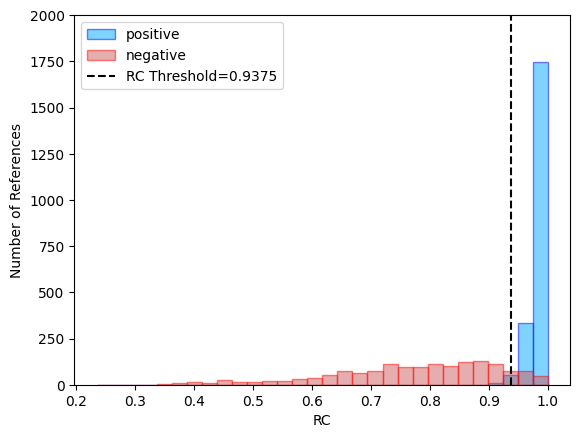

In [13]:
# Cell 43
# figureを生成する
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 2つのリストを結合
all_data = numpy.concatenate((positive_sim_r_list,negative_sim_r_list))
min_val = all_data.min()
max_val = all_data.max()
# 階級の数
num_bins = 30
# 階級の境界値
bins = numpy.linspace(min_val, max_val, num_bins + 1)
# axesにplot
ax.hist(positive_sim_r_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label="positive")
ax.hist(negative_sim_r_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.axvline(config.RC_THRESHOLD,color="black",linestyle="--",label=f"RC Threshold={config.RC_THRESHOLD}")
plt.ylim(0,2000)
#plt.title('Figure 5    Score distribution(sim_r)')
plt.xlabel("RC")
plt.ylabel("Number of References")
plt.legend(loc="upper left")
plt.show()

### Cell 44
#### 参考文献文字列（実在）

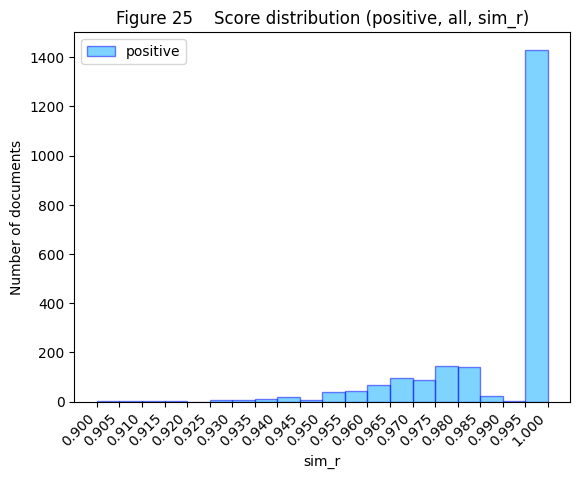

In [43]:
# Cell 45
# figureを生成
fig = plt.figure()
# axにfigureを設定
ax = fig.add_subplot(1,1,1)
# 階級値
bins = [0.900, 0.905, 0.910, 0.915, 0.920, 0.925, 0.930, 0.935, 0.940, 0.945, 0.950, 0.955, 0.960, 0.965, 0.970, 0.975, 0.980, 0.985, 0.990, 0.995, 1.000]
# axesにプロット
ax.hist(positive_sim_r_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label='positive')
# 表示
plt.xticks(ticks=bins, labels=[f'{b:.3f}' for b in bins], rotation=45, ha='right')
plt.title('Figure 25    Score distribution (positive, all, sim_r)')
plt.xlabel('sim_r')
plt.ylabel('Number of documents')
plt.legend(loc="upper left")
plt.show()

### Cell 46
#### 参考文献文字列（架空）

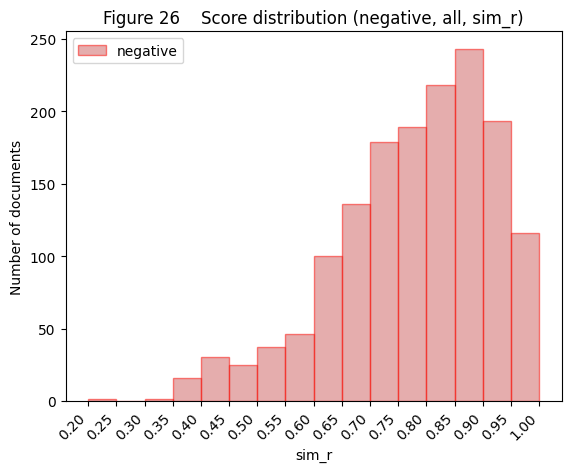

In [44]:
# Cell 47
# figure の作成
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 階級値の設定
bins = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
# axesにプロット
ax.hist(negative_sim_r_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.xticks(ticks=bins, labels=[f'{b:.2f}' for b in bins], rotation=45, ha='right')
plt.title('Figure 26    Score distribution (negative, all, sim_r)')
plt.xlabel('sim_r')
plt.ylabel('Number of documents')
plt.legend(loc="upper left")
plt.show()


### Cell 48
### CCの分布

### Cell 49
#### 参考文献文字列（実在）

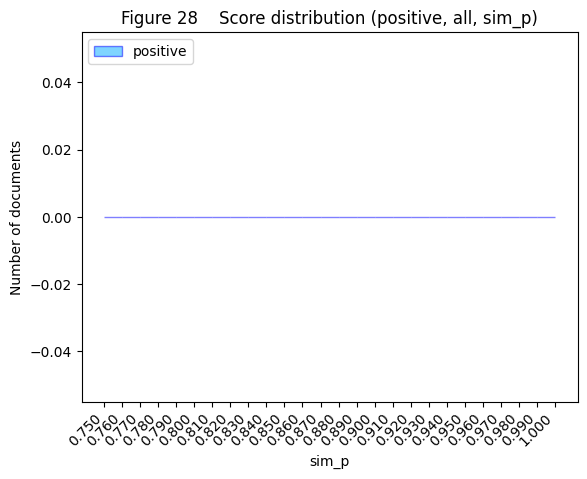

In [17]:
# Cell 50
# figureを生成
fig = plt.figure()
# axにfigureを設定
ax = fig.add_subplot(1,1,1)
# 階級値
bins = [0.75, 0.76, 0.77, 0.78, 0.79, 0.80, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00]
# axesにプロット
ax.hist(positive_sim_p_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label='positive')
# 表示
plt.xticks(ticks=bins, labels=[f'{b:.3f}' for b in bins], rotation=45, ha='right')
plt.title('Figure 28    Score distribution (positive, all, sim_p)')
plt.xlabel('sim_p')
plt.ylabel('Number of documents')
plt.legend(loc="upper left")
plt.show()

### Cell 51
#### 参考文献文字列（架空）

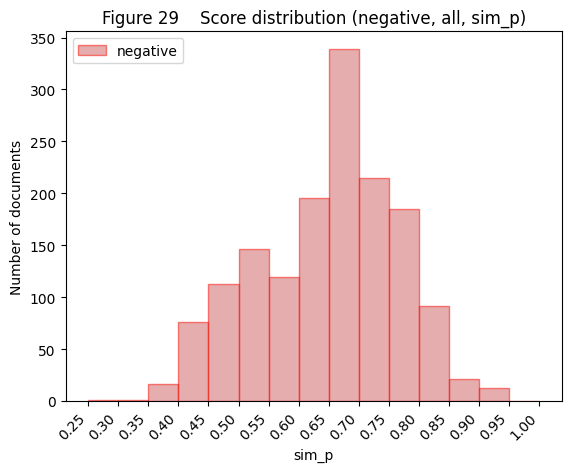

In [47]:
# Cell 52
# figure の作成
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 階級値の設定
bins = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
# axesにプロット
ax.hist(negative_sim_p_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.xticks(ticks=bins, labels=[f'{b:.2f}' for b in bins], rotation=45, ha='right')
plt.title('Figure 29    Score distribution (negative, all, sim_p)')
plt.xlabel('sim_p')
plt.ylabel('Number of documents')
plt.legend(loc="upper left")
plt.show()


### Cell 53
#### 参考文献文字列（実在・架空）

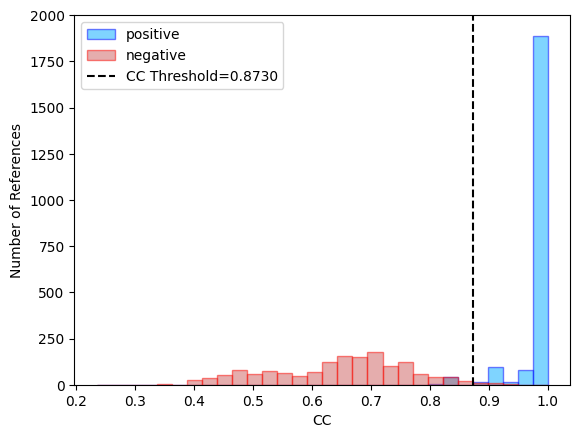

In [24]:
# Cell 54
# figureを生成する
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 2つのリストを結合
all_data = numpy.concatenate((positive_sim_r_list,negative_sim_r_list))
min_val = all_data.min()
max_val = all_data.max()
# 階級の数
num_bins = 30
# 階級の境界値
bins = numpy.linspace(min_val, max_val, num_bins + 1)
# axesにplot
ax.hist(positive_sim_p_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label="positive")
ax.hist(negative_sim_p_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.axvline(config.CC_THRESHOLD,color="black",linestyle="--",label=f"CC Threshold={config.CC_THRESHOLD:.4f}")
plt.ylim(0,2000)
#plt.title('Figure 6    Score distribution(sim_p)')
plt.xlabel("CC")
plt.ylabel("Number of References")
plt.legend(loc="upper left")
plt.show()

### Cell 55
### BM25（非正規化）

### Cell 56
#### 参考文献文字列（実在）

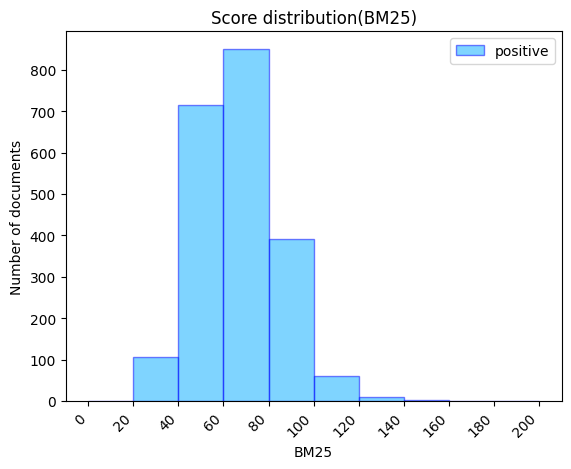

最小値：23.543577
最大値：183.40448


In [39]:
# Cell 57
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
bins = [0,20,40,60,80,100,120,140,160,180,200]
ax.hist(positive_BM25_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label="positive")

plt.xticks(ticks=bins, labels=[f'{b}' for b in bins], rotation=45, ha='right')
plt.title("Score distribution(BM25)")
plt.xlabel('BM25')
plt.ylabel('Number of documents')
plt.legend(loc="upper right")
plt.show()
print(f"最小値：{min(positive_BM25_list)}")
print(f"最大値：{max(positive_BM25_list)}")

### Cell 58
#### 参考文献文字列（架空）

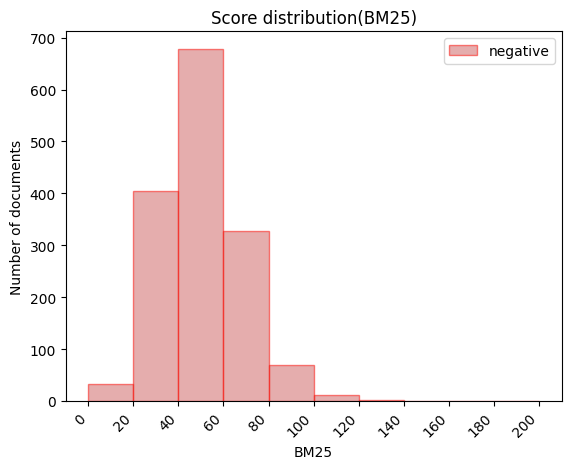

最小値：10.688017
最大値：173.4817


In [40]:
# Cell 59
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
bins = [0,20,40,60,80,100,120,140,160,180,200]
ax.hist(negative_BM25_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")

plt.xticks(ticks=bins, labels=[f'{b}' for b in bins], rotation=45, ha='right')
plt.title("Score distribution(BM25)")
plt.xlabel('BM25')
plt.ylabel('Number of documents')
plt.legend(loc="upper right")
plt.show()
print(f"最小値：{min(negative_BM25_list)}")
print(f"最大値：{max(negative_BM25_list)}")

### Cell 60
#### 参考文献文字列（実在・架空）

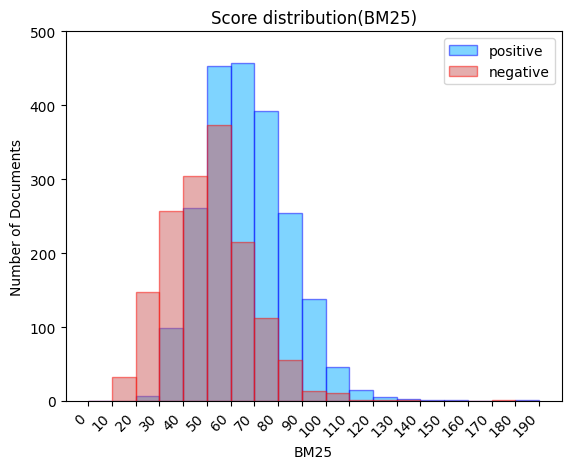

In [44]:
# Cell 61
# figureを生成する
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 境界値
bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190]
# axesにplot
ax.hist(positive_BM25_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label="positive")
ax.hist(negative_BM25_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.xticks(ticks=bins, labels=[f'{b}' for b in bins], rotation=45, ha='right')
plt.ylim(0,500)
plt.title('Score distribution(BM25)')
plt.xlabel("BM25")
plt.ylabel("Number of Documents")
plt.legend(loc="upper right")
plt.show()

### Cell 62
### BM25（正規化）

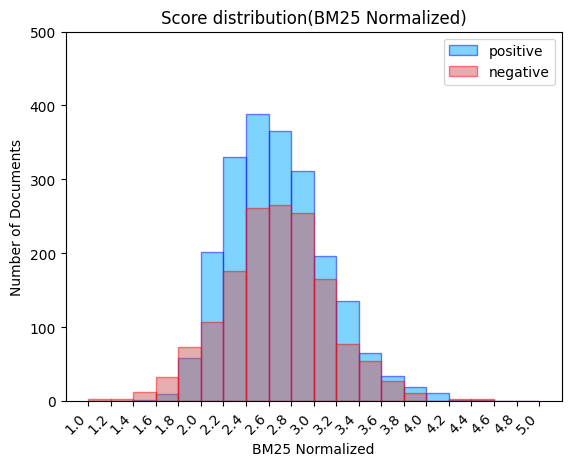

In [19]:
# Cell 63
# figureを生成する
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 境界値
bins = [x*0.2+1 for x in range(0,21,1)]
# axesにplot
ax.hist(positive_BM25_normalized_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label="positive")
ax.hist(negative_BM25_normalized_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.xticks(ticks=bins, labels=[f'{b:.1f}' for b in bins], rotation=45, ha='right')
plt.ylim(0,500)
plt.title('Score distribution(BM25 Normalized)')
plt.xlabel("BM25 Normalized")
plt.ylabel("Number of Documents")
plt.legend(loc="upper right")
plt.show()

### Cell 64
### 散布図の作成

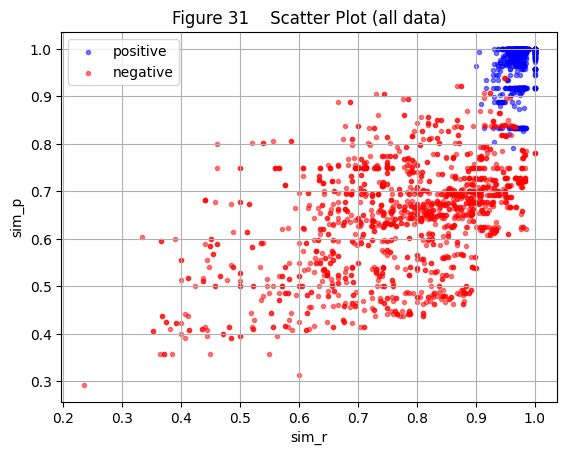

In [49]:
# Cell 65
# figureを作成する
fig = plt.figure()
# axをfigureに設定する
ax = fig.add_subplot(1,1,1)
# プロット
ax.scatter(positive_sim_r_list,positive_sim_p_list,c="blue",marker=".",alpha=0.5,label="positive")
ax.scatter(negative_sim_r_list,negative_sim_p_list,c="red",marker=".",alpha=0.5,label="negative")
# 表示
ax.grid(True)
ax.set_title("Figure 31    Scatter Plot (all data)")
ax.set_xlabel("sim_r")
ax.set_ylabel("sim_p")
ax.legend(loc="upper left")
plt.show()

### Cell 66
## 閾値の決定

### Cell 67
### scikit-learn のインストール
* インストール済みの場合、インストール不要

In [50]:
# Cell 68
!pip3 install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 58.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 55.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


### Cell 69
### RC

In [18]:
# Cell 70
# 全てのスコアとラベルを結合
all_scores_sim_r = positive_sim_r_list + negative_sim_r_list
all_labels_sim_r = [1] * len(positive_sim_r_list) + [0] * len(negative_sim_r_list)

### Cell 71
#### ROC曲線とAUCによる閾値の決定【没】

In [10]:
# Cell 72
from sklearn.metrics import roc_curve
import numpy as np

# TPR, FPR, 閾値を計算
fpr, tpr, thresholds = roc_curve(all_labels_sim_r, all_scores_sim_r)

# 左上隅（0,1）に最も近い閾値を求める
distances = np.sqrt((1 - tpr)**2 + fpr**2)
optimal_threshold_roc_sim_r = thresholds[np.argmin(distances)]

print(f"ROC曲線に基づく最適な閾値: {optimal_threshold_roc_sim_r}")

ROC曲線に基づく最適な閾値: 0.9545454545454546


### Cell 73
#### F1スコアによる閾値の決定

In [11]:
# Cell 74
from sklearn.metrics import f1_score

best_f1 = 0
optimal_threshold_f1_sim_r = 0

for t in thresholds:
    y_pred = [1 if score >= t else 0 for score in all_scores_sim_r]
    current_f1 = f1_score(all_labels_sim_r, y_pred)
    if current_f1 > best_f1:
        best_f1 = current_f1
        optimal_threshold_f1_sim_r = t

print(f"F1スコアに基づく最適な閾値: {optimal_threshold_f1_sim_r}")

F1スコアに基づく最適な閾値: 0.9375


### Cell 75
### CC

In [20]:
# Cell 76
# 全てのスコアとラベルを結合
all_scores_sim_p = positive_sim_p_list + negative_sim_p_list
all_labels_sim_p = [1] * len(positive_sim_p_list) + [0] * len(negative_sim_p_list)

### Cell 77
#### ROC曲線とAUCによる閾値の決定【没】

In [79]:
# Cell 78
from sklearn.metrics import roc_curve
import numpy as np

# TPR, FPR, 閾値を計算
fpr, tpr, thresholds = roc_curve(all_labels_sim_p, all_scores_sim_p)

# 左上隅（0,1）に最も近い閾値を求める
distances = np.sqrt((1 - tpr)**2 + fpr**2)
optimal_threshold_roc_sim_p = thresholds[np.argmin(distances)]

print(f"ROC曲線に基づく最適な閾値: {optimal_threshold_roc_sim_p}")

ROC曲線に基づく最適な閾値: 0.873015873015873


### Cell 79
#### F1スコアによる閾値の決定

In [80]:
# Cell 80
from sklearn.metrics import f1_score

best_f1 = 0
optimal_threshold_f1_sim_p = 0

for t in thresholds:
    y_pred = [1 if score >= t else 0 for score in all_scores_sim_p]
    current_f1 = f1_score(all_labels_sim_p, y_pred)
    if current_f1 > best_f1:
        best_f1 = current_f1
        optimal_threshold_f1_sim_p = t

print(f"F1スコアに基づく最適な閾値: {optimal_threshold_f1_sim_p}")

F1スコアに基づく最適な閾値: 0.873015873015873


### Cell 81
### 閾値込みのヒストグラム

### Cell 82
#### RC

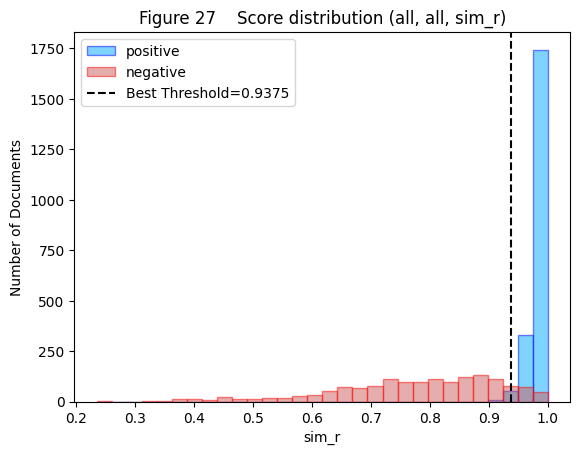

In [84]:
# Cell 83
# figureを生成する
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 2つのリストを結合
all_data = numpy.concatenate((positive_sim_r_list,negative_sim_r_list))
min_val = all_data.min()
max_val = all_data.max()
# 階級の数
num_bins = 30
# 階級の境界値
bins = numpy.linspace(min_val, max_val, num_bins + 1)
# axesにplot
ax.hist(positive_sim_r_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label="positive")
ax.hist(negative_sim_r_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.axvline(optimal_threshold_f1_sim_r,color="black",linestyle="--",label=f"Best Threshold={optimal_threshold_f1_sim_r}")
plt.title('Figure 27    Score distribution (all, all, sim_r)')
plt.xlabel("sim_r")
plt.ylabel("Number of Documents")
plt.legend(loc="upper left")
plt.show()

### Cell 84
#### CC

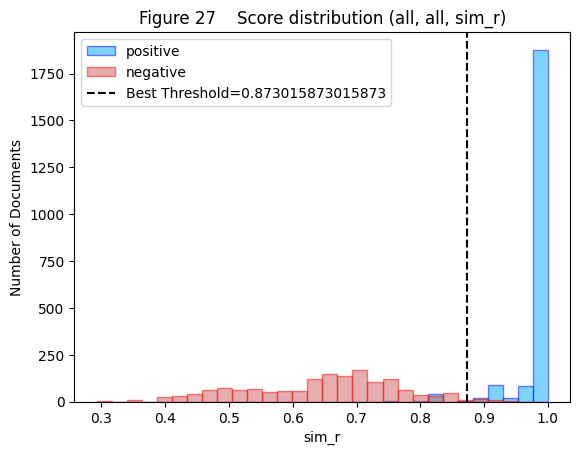

In [85]:
# Cell 85
# figureを生成する
fig = plt.figure()
# axにfigureを設定する
ax = fig.add_subplot(1,1,1)
# 2つのリストを結合
all_data = numpy.concatenate((positive_sim_p_list,negative_sim_p_list))
min_val = all_data.min()
max_val = all_data.max()
# 階級の数
num_bins = 30
# 階級の境界値
bins = numpy.linspace(min_val, max_val, num_bins + 1)
# axesにplot
ax.hist(positive_sim_p_list,bins=bins,color="#00AAFF",ec="#0000FF",alpha=0.5,label="positive")
ax.hist(negative_sim_p_list,bins=bins,color="indianred",ec="#FA0800",alpha=0.5,label="negative")
# 表示
plt.axvline(optimal_threshold_f1_sim_p,color="black",linestyle="--",label=f"Best Threshold={optimal_threshold_f1_sim_p}")
plt.title('Figure 27    Score distribution (all, all, sim_r)')
plt.xlabel("sim_r")
plt.ylabel("Number of Documents")
plt.legend(loc="upper left")
plt.show()

### Cell 86
### その他(RC)

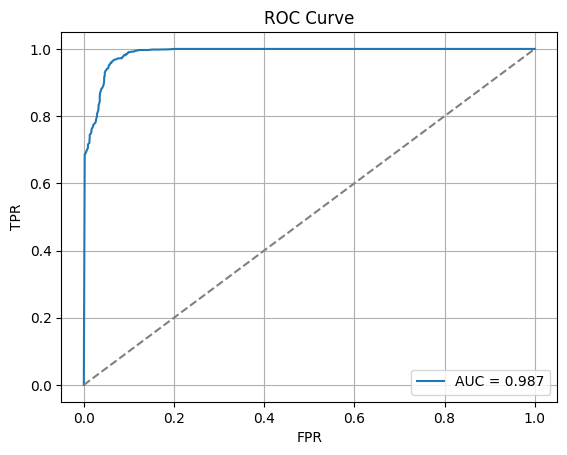

In [21]:
# Cell 87
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(all_labels_sim_r, all_scores_sim_r)
auc = roc_auc_score(all_labels_sim_r, all_scores_sim_r)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import numpy as np

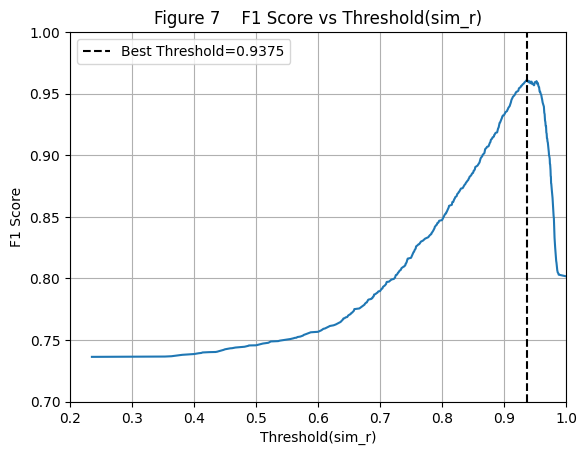

Best Threshold: 0.9375


In [26]:
# Cell 88
from sklearn.metrics import f1_score

f1_scores = [f1_score(all_labels_sim_r, (all_scores_sim_r >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

plt.plot(thresholds, f1_scores)
plt.xlim(0.2, 1.0) # 横軸の範囲
plt.ylim(0.70, 1.00) # 縦軸の範囲
plt.axvline(best_t,color="black",linestyle="--",label=f"Best Threshold={best_t}")
plt.legend(loc="upper left")
plt.xlabel("Threshold(sim_r)")
plt.ylabel("F1 Score")
plt.title("Figure 7    F1 Score vs Threshold(sim_r)")
plt.grid(True)
plt.show()
print(f"Best Threshold: {best_t}")

### Cell 89
###  その他(CC)

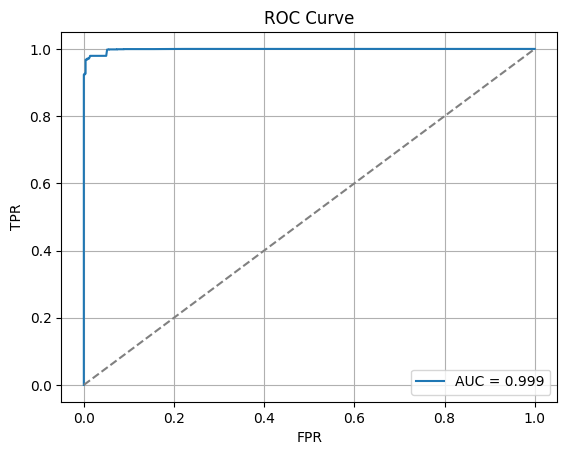

In [28]:
# Cell 90
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(all_labels_sim_p, all_scores_sim_p)
auc = roc_auc_score(all_labels_sim_p, all_scores_sim_p)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

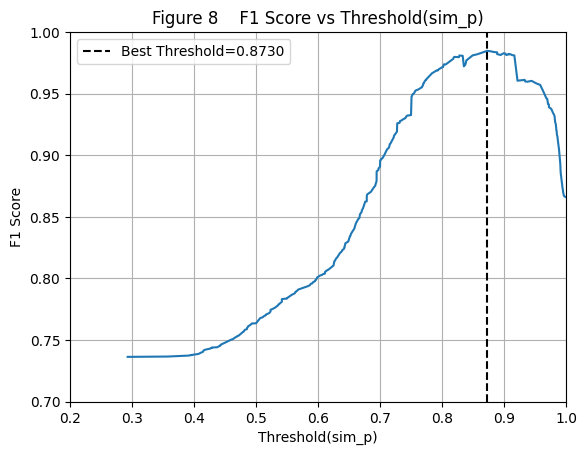

Best Threshold: 0.873015873015873


In [29]:
# Cell 91
from sklearn.metrics import f1_score

f1_scores = [f1_score(all_labels_sim_p, (all_scores_sim_p >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

plt.plot(thresholds, f1_scores)
plt.xlim(0.2, 1.0) # 横軸の範囲
plt.ylim(0.70, 1.00) # 縦軸の範囲
plt.axvline(best_t,color="black",linestyle="--",label=f"Best Threshold={best_t:.4f}")
plt.legend(loc="upper left")
plt.xlabel("Threshold(sim_p)")
plt.ylabel("F1 Score")
plt.title("Figure 8    F1 Score vs Threshold(sim_p)")
plt.grid(True)
plt.show()
print(f"Best Threshold: {best_t}")

### Cell 92
### BM25（非正規化）

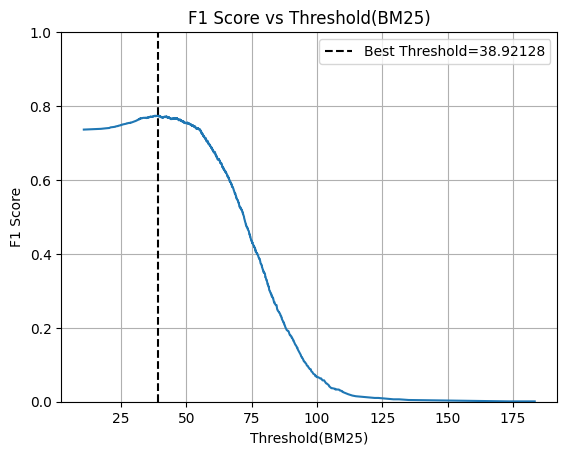

Best Threshold: 38.92128


In [30]:
# Cell 93
# モジュールの読み込み
from sklearn.metrics import f1_score
# 全てのスコアとラベルを結合
all_scores_BM25 = positive_BM25_list + negative_BM25_list
all_labels_BM25 = [1] * len(positive_BM25_list) + [0] * len(negative_BM25_list)
# 算出処理
fpr, tpr, thresholds = roc_curve(all_labels_BM25, all_scores_BM25)
f1_scores = [f1_score(all_labels_BM25, (all_scores_BM25 >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

plt.plot(thresholds, f1_scores)
plt.axvline(best_t,color="black",linestyle="--",label=f"Best Threshold={best_t}")
plt.ylim(0,1.0)
plt.legend(loc="upper right")
plt.xlabel("Threshold(BM25)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold(BM25)")
plt.grid(True)
plt.show()
print(f"Best Threshold: {best_t}")

### Cell 94
### BM25（正規化）

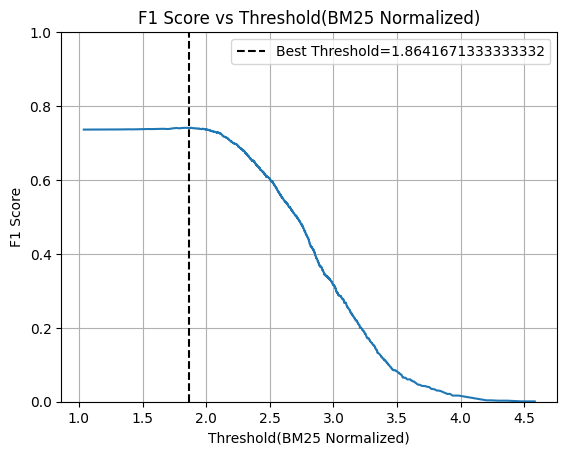

Best Threshold: 1.8641671333333332


In [31]:
# Cell 95
# モジュールの読み込み
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
import numpy as np
# 全てのスコアとラベルを結合
all_scores_BM25_normalized = positive_BM25_normalized_list + negative_BM25_normalized_list
all_labels_BM25_normalized = [1] * len(positive_BM25_normalized_list) + [0] * len(negative_BM25_normalized_list)
# 算出処理
fpr, tpr, thresholds = roc_curve(all_labels_BM25_normalized, all_scores_BM25_normalized)
f1_scores = [f1_score(all_labels_BM25_normalized, (all_scores_BM25_normalized >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

plt.plot(thresholds, f1_scores)
plt.axvline(best_t,color="black",linestyle="--",label=f"Best Threshold={best_t}")
plt.ylim(0,1.0)
plt.legend(loc="upper right")
plt.xlabel("Threshold(BM25 Normalized)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold(BM25 Normalized)")
plt.grid(True)
plt.show()
print(f"Best Threshold: {best_t}")

### Cell 96
### MC

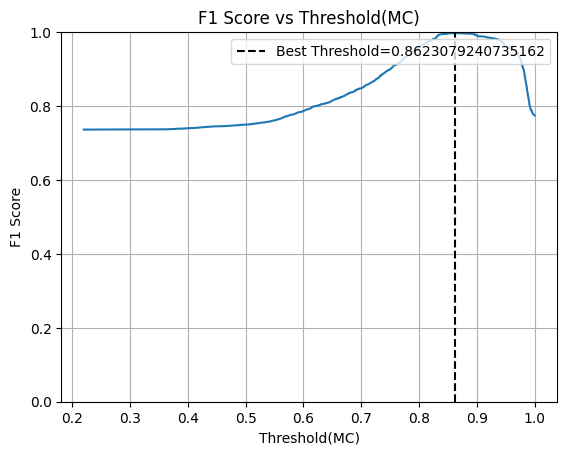

Best Threshold: 0.8623079240735162


In [32]:
# Cell 97
# モジュールの読み込み
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
import numpy as np
# 全てのスコアとラベルを結合
all_scores_mc = positive_mc_list + negative_mc_list
all_labels_mc = [1] * len(positive_mc_list) + [0] * len(negative_mc_list)
# 算出処理
fpr, tpr, thresholds = roc_curve(all_labels_mc, all_scores_mc)
f1_scores = [f1_score(all_labels_mc, (all_scores_mc >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

plt.plot(thresholds, f1_scores)
plt.axvline(best_t,color="black",linestyle="--",label=f"Best Threshold={best_t}")
plt.ylim(0,1.0)
plt.legend(loc="upper right")
plt.xlabel("Threshold(MC)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold(MC)")
plt.grid(True)
plt.show()
print(f"Best Threshold: {best_t}")